In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils.common import extract_latents_with_names, combine_audio_lyrics_and_genre
from run_models import run_VAE, run_KMeans, run_Agglomerative, run_DBSCAN

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np, pandas as pd
from pathlib import Path

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

In [6]:
METADATA_FILE = root / config.METADATA_DIR / "metadata_en.csv"

In [7]:
METADATA_FILE.exists() # must be true

True

In [8]:
df_meta = pd.read_csv(METADATA_FILE)
df_meta.head()

,audio_file_stem,lyric_file_stem,quadrant,genres,label
0,A001,L051,Q4,"Jazz,Vocal Jazz,Traditional Pop,Early Pop/Rock...",2
1,A002,L052,Q4,Pop/Rock,2
2,A003,L053,Q3,"Soul,Pop-Soul,Smooth Soul,R&B",3
3,A004,L054,Q3,"Outlaw Country,Country",3
4,A005,L055,Q1,"Dance-Rock,R&B,Contemporary Pop/Rock,Contempor...",0


### check that config.VAE_TYPE = "conv" and config.MODEL_TYPE = "cvae"

In [9]:
config.VAE_TYPE, config.MODEL_TYPE

('conv', 'cvae')

In [10]:
cvae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="cvae", root=root, plot_dir_name="hard_3_cvae_audio_lyrics_genre")

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-10 09:05:20,439] A new study created in memory with name: Conditional VAE Tuning


Creating fresh trials directory...


  0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 478.4047     | 276.7096    
Recon        | 413.7066     | 273.7970    
KL Div       | 323.4904     | 14.5627     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 382.3362     | 300.3631    
Recon        | 341.3616     | 289.4137    
KL Div       | 204.8726     | 54.7469     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 442.1881     | 264.0178    
Recon        | 344.9030     | 256.0134    
KL Div       | 486.4253     | 40.0222     
--------------------------------------

Best trial: 0. Best value: 123.703:  20%|██        | 1/5 [00:06<00:27,  6.96s/it]

...

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 192.0019     | 95.0635     
Recon        | 171.6247     | 83.7573     
KL Div       | 101.8857     | 56.5310     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 86.1982      | 74.0470     
Recon        | 75.2452      | 64.5528     
KL Div       | 54.7651      | 47.4712     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 73.2035      | 71.4849     
Recon        | 63.2488      | 62.7683     
KL Div       | 49.7735      | 43.5831     
--------------------------------------

Best trial: 1. Best value: 62.0994:  80%|████████  | 4/5 [01:07<00:14, 14.46s/it]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 63.7900      | 61.1472     
Recon        | 54.7467      | 51.9888     
KL Div       | 45.2165      | 45.7924     
--------------------------------------------------

[I 2026-04-10 09:06:28,009] Trial 4 finished with value: 49.51022527635712 and parameters: {'CHANNEL_1': 8, 'CHANNEL_2_MULTIPLIER': 2, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 32, 'LR': 0.0002572663133249957, 'BATCH_SIZE': 16, 'BETA': 3.0}. Best is trial 4 with value: 49.51022527635712.


Best trial: 4. Best value: 49.5102: 100%|██████████| 5/5 [01:07<00:00, 13.55s/it]


..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots
Saved: ..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots\optimization_history.html
Saved: ..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots\param_importances.html
Saved: ..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots\parallel_coordinate.html
Saved: ..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots\edf.html
Saved: ..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots\timeline.html
Saved: ..\..\results\trials\hard_3_cvae_audio_lyrics_genre\plots\contour.html
Best trial for `cvae`:
Score: 49.5102
    CHANNEL_1                 8
    CHANNEL_2_MULTIPLIER      2
    CHANNEL_3_MULTIPLIER      4
    LATENT_DIM                32
    LR                        0.0002572663133249957
    BATCH_SIZE                16
    BETA                      3.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Bat

In [11]:
train_latents, train_labels, train_audio_names = extract_latents_with_names(model=cvae, loader=train_loader, device=device)
test_latents, test_labels, test_audio_names  = extract_latents_with_names(model=cvae, loader=test_loader,  device=device)

In [12]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)
vae_labels = np.concatenate([train_labels, test_labels], axis=0)
vae_audio_names = np.concatenate([train_audio_names, test_audio_names], axis=0)

In [13]:
vae_latents.shape

(2424, 32)

### genres are in-row w metadata - have to encode everytime

In [14]:
latent_vecs_hybrid = combine_audio_lyrics_and_genre(latent_vecs=vae_latents, audio_names=vae_audio_names, labeled_df=df_meta, root=root)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11951.90it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
latent_vecs_hybrid.shape

(2424, 1184)




Optimal k        : 5
Inertia (WCSS)   : 42043.3555
Silhouette Score : 0.1942
CH Index         : 495.7044
DB Index         : 1.6080
ARI              : 0.0527
NMI              : 0.0740
Purity           : 0.3688



n_clusters not provided for Agglomerative — running elbow method to determine k...



Agglomerative  n_clusters=5  linkage='ward'
Silhouette Score : 0.1680
CH Index         : 436.7626
DB Index         : 1.5877
ARI              : 0.0530
NMI              : 0.0783
Purity           : 0.3696






DBSCAN  eps=2.5  min_samples=5
Clusters found   : 24
Noise points     : 1527



DB-SCAN
Silhouette Score : -0.2267
CH Index         : 32.7608
DB Index         : 1.6945
ARI              : 0.0138
NMI              : 0.1945
Purity           : 0.5530





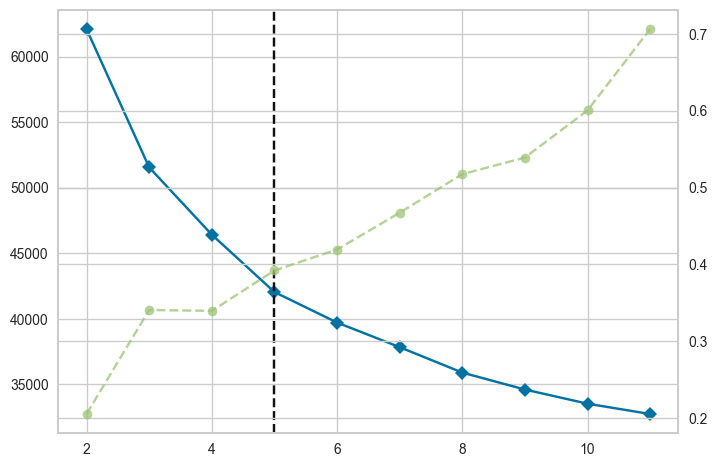

In [16]:
vae_kmeans, vae_kmeans_metrics = run_KMeans(latent_vecs_hybrid, model_type="hard_3_cvae_audio_lyrics_genre", true_labels=vae_labels, root=root)
vae_agglomerative, vae_agglomerative_metrics = run_Agglomerative(latent_vecs_hybrid, model_type="hard_3_cvae_audio_lyrics_genre", true_labels=vae_labels, root=root)
vae_dbscan, vae_dbscan_metrics = run_DBSCAN(latent_vecs_hybrid, model_type="hard_3_cvae_audio_lyrics_genre", true_labels=vae_labels, root=root)

In [17]:
from collections import Counter

for cluster_id in range(len(vae_kmeans.cluster_centers_)):
    mask = vae_kmeans.labels_ == cluster_id
    genre_counts = Counter(vae_labels[mask])
    print(f"Cluster {cluster_id}: {genre_counts}")

Cluster 0: Counter({np.int64(1): 178, np.int64(3): 98, np.int64(0): 69, np.int64(2): 66})
Cluster 1: Counter({np.int64(2): 283, np.int64(3): 254, np.int64(0): 216, np.int64(1): 122})
Cluster 2: Counter({np.int64(2): 54, np.int64(3): 54, np.int64(0): 52, np.int64(1): 51})
Cluster 3: Counter({np.int64(1): 248, np.int64(0): 234, np.int64(3): 89, np.int64(2): 76})
Cluster 4: Counter({np.int64(2): 131, np.int64(3): 111, np.int64(0): 36, np.int64(1): 2})


In [18]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [19]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\hard_3_cvae_audio_lyrics_genre


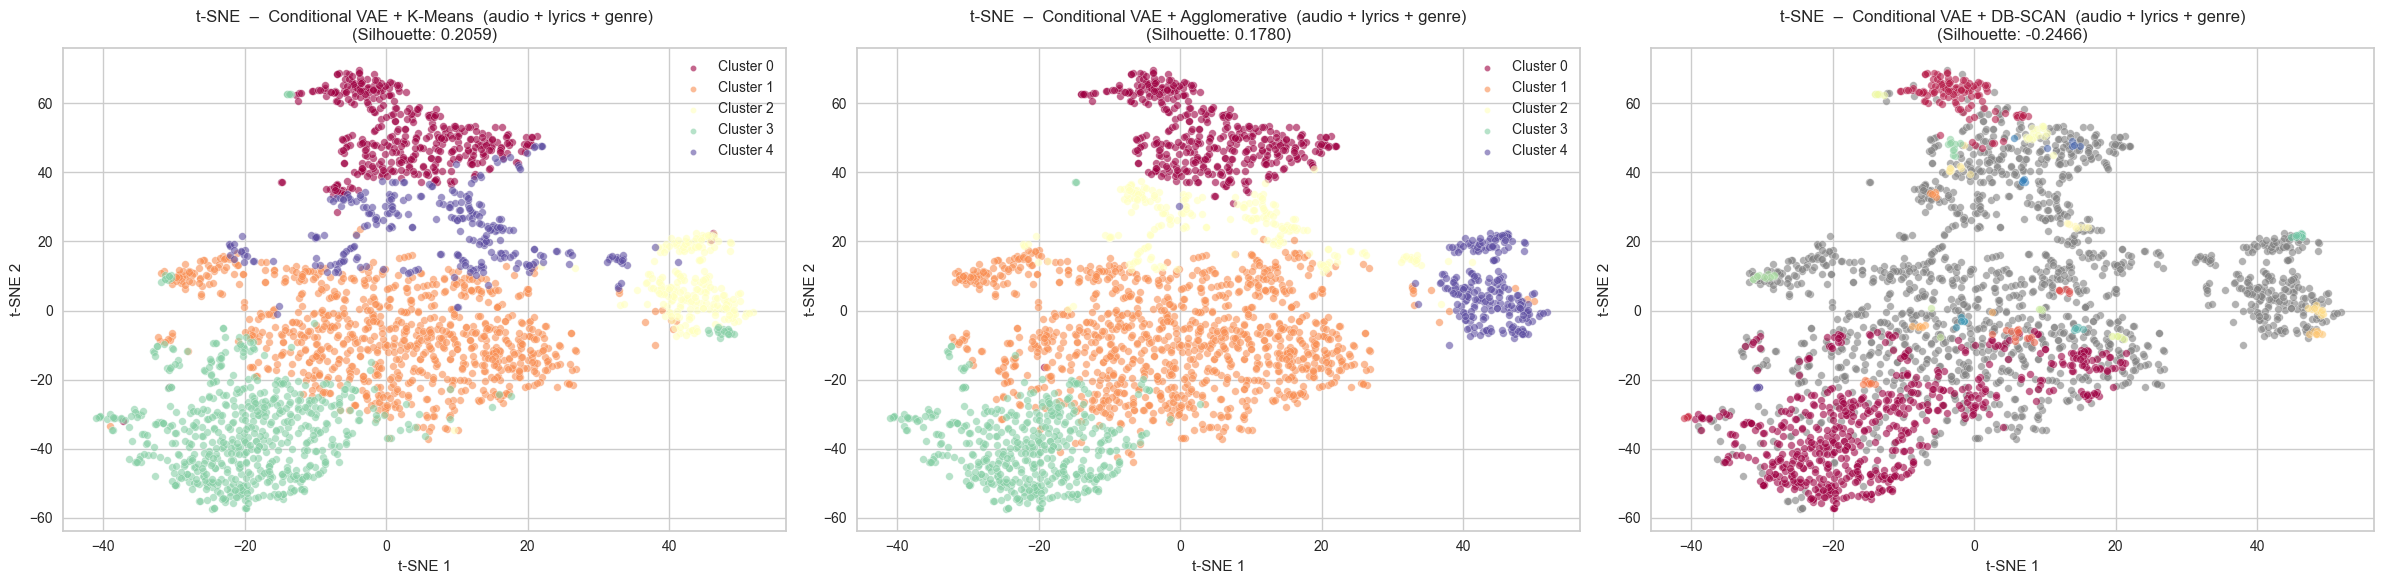

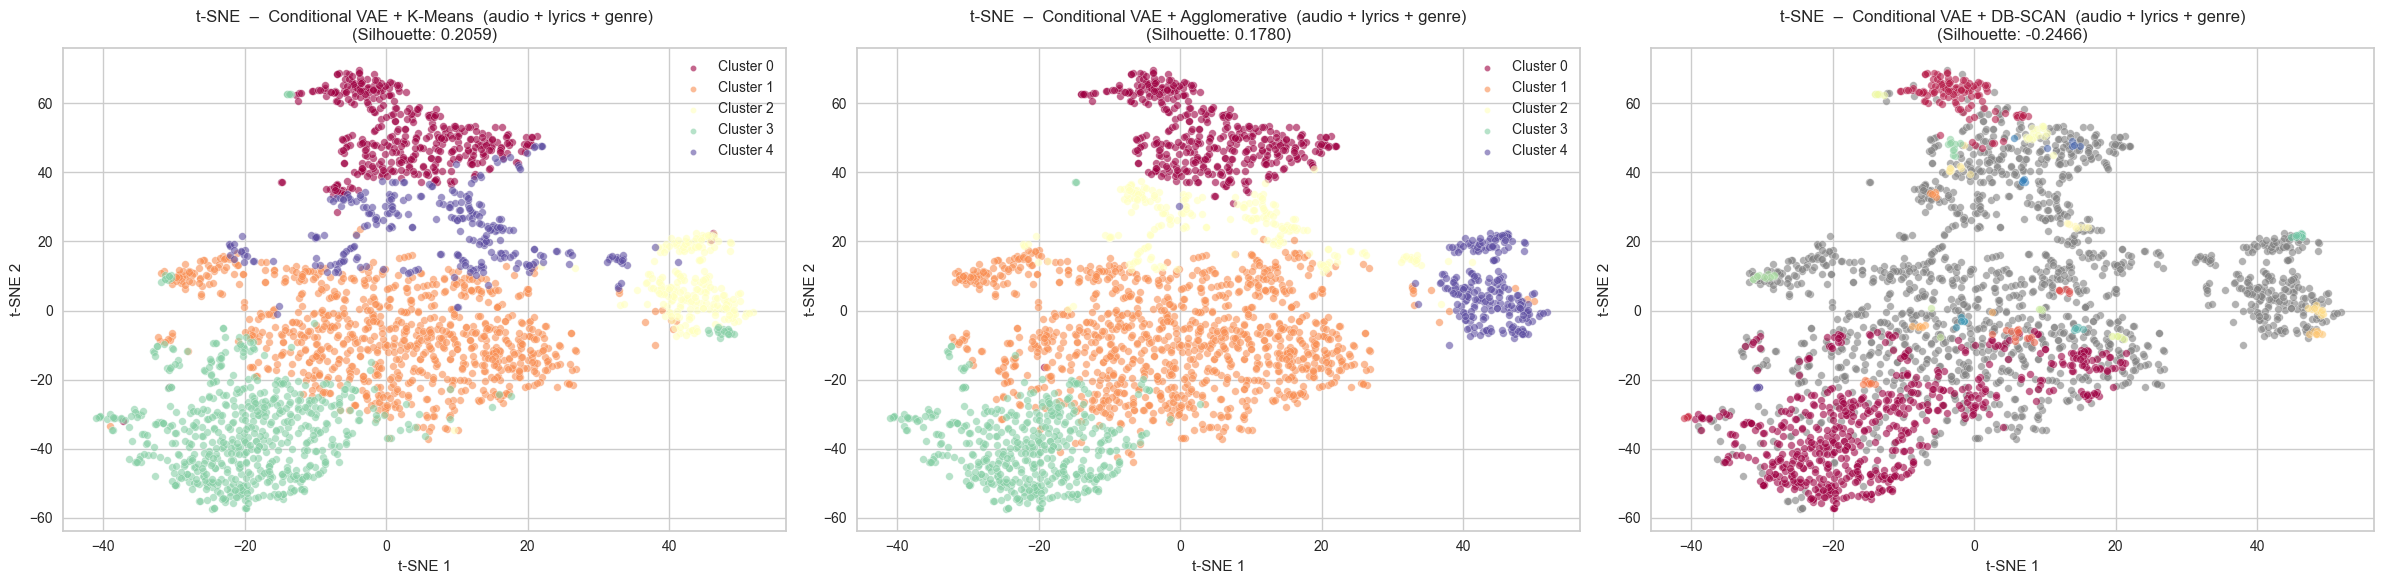

In [20]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, vae_agglomerative.labels_, vae_dbscan.labels_],
    ["Conditional VAE + K-Means  (audio + lyrics + genre)", "Conditional VAE + Agglomerative  (audio + lyrics + genre)", "Conditional VAE + DB-SCAN  (audio + lyrics + genre)"],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_), silhouette_score(vae_latents, vae_agglomerative.labels_), silhouette_score(vae_latents, vae_dbscan.labels_)],
    save_path=TSNE_DIR / "hard_3_cvae_audio_lyrics_genre"
)